# N-Pendulum Chain — When Does Complexity Explode?

**Author:** Nikola Kolev 
**Course:** Math Concepts for Developers, SoftUni 2026  

---

## Research Question

A chain of N pendulums attached to each other is one of the simplest physical systems that exhibits chaotic behavior. But how exactly does chaos grow with the number of pendulums? Does it grow linearly, exponentially, or is there a critical N after which the system is always chaotic?

This project investigates:
- how the Lyapunov exponent λ changes for N = 2 to 8
- how the fractal dimension of the phase space changes with N
- which initial conditions lead to chaos and which lead to predictable motion
- how damping (friction) destroys chaos

All parameters (mass, length, initial angles) are fully controlled — no real-world data, pure mathematical model. This means all results are exact and reproducible.

In [1]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
%matplotlib inline

## 1. Mathematical Model — Lagrangian Mechanics

To describe the motion of N pendulums we use **Lagrangian mechanics** instead of Newtonian mechanics. With N coupled pendulums, the constraint forces between them are extremely complex to describe directly. The Lagrangian approach bypasses them entirely by working only with energies.

### Generalized Coordinates

We describe the system using only the angles θ₁, θ₂, ..., θₙ — one per pendulum. The position of the i-th pendulum in Cartesian coordinates is:

$$x_i = \sum_{k=1}^{i} l_k \sin(\theta_k)$$

$$y_i = -\sum_{k=1}^{i} l_k \cos(\theta_k)$$

### The Lagrangian

The Lagrangian L = T - V is the difference between kinetic and potential energy:

$$L = \sum_{i=1}^{N} \left( \frac{1}{2} m_i v_i^2 - m_i g y_i \right)$$

where $v_i^2 = \dot{x}_i^2 + \dot{y}_i^2$ is the squared velocity of the i-th pendulum.

### Euler-Lagrange Equations

The equations of motion follow from:

$$\frac{d}{dt}\frac{\partial L}{\partial \dot{\theta}_i} - \frac{\partial L}{\partial \theta_i} = 0, \quad i = 1, ..., N$$

This gives a system of N coupled nonlinear second-order ODEs. For N=2 this is the well-known double pendulum. For N>2 symbolic derivation becomes computationally expensive — motivating the numerical approach below.

### Assumptions
- All rods are massless and rigid
- Pivot points are frictionless unless explicitly modeled
- Motion is constrained to a 2D plane
- Gravitational acceleration g = 9.81 m/s²

In [2]:
t = sp.Symbol('t')
g = sp.Symbol('g', positive=True)

def make_pendulum(i):
    m = sp.Symbol(f'm{i}', positive=True)
    l = sp.Symbol(f'l{i}', positive=True)
    theta = sp.Function(f'theta{i}')(t)
    return m, l, theta

In [3]:
def get_positions(thetas, lengths):
    x, y = sp.Integer(0), sp.Integer(0)
    positions = []
    
    for i, (theta, l) in enumerate(zip(thetas, lengths)):
        x = x + l * sp.sin(theta)
        y = y - l * sp.cos(theta)
        positions.append((x, y))
    
    return positions

In [4]:
def get_lagrangian(masses, lengths, n):
    thetas, ls, ms = [], [], []
    
    for i in range(n):
        m, l, theta = make_pendulum(i + 1)
        thetas.append(theta)
        ls.append(l)
        ms.append(m)
    
    positions = get_positions(thetas, ls)
    L = sp.Integer(0)
    
    for i in range(n):
        x, y = positions[i]
        
        vx = sp.diff(x, t)
        vy = sp.diff(y, t)
        
        T_i = sp.Rational(1, 2) * ms[i] * (vx**2 + vy**2)
        V_i = ms[i] * g * y
        L = L + T_i - V_i
    
    return L, thetas, ms, ls

In [5]:
def get_equations_of_motion(L, thetas):
    eqs = []
    
    for theta in thetas:
        theta_dot = sp.diff(theta, t)
        
        dL_dtheta = sp.diff(L, theta)
        dL_dtheta_dot = sp.diff(L, theta_dot)
        d_dt_dL_dtheta_dot = sp.diff(dL_dtheta_dot, t)
        
        eq = d_dt_dL_dtheta_dot - dL_dtheta
        eqs.append(eq)
    
    return eqs

In [6]:
def solve_for_accelerations(eqs, thetas):
    theta_ddots = [sp.diff(sp.diff(theta, t), t) for theta in thetas]
    solution = sp.solve(eqs, theta_ddots)
    return solution, theta_ddots

In [7]:
def build_numerical_system(solution, thetas, masses, lengths, g_val=9.81, n=2):
    theta_dots = [sp.diff(theta, t) for theta in thetas]
    theta_ddots = [sp.diff(sp.diff(theta, t), t) for theta in thetas]
    
    subs = {g: g_val}
    for i in range(n):
        subs[masses[i]] = masses[i]
        subs[lengths[i]] = lengths[i]
    
    all_vars = thetas + theta_dots
    
    acc_funcs = []
    for ddot in theta_ddots:
        expr = solution[ddot].subs(subs)
        expr = sp.simplify(expr)
        f = sp.lambdify(all_vars, expr, modules='numpy')
        acc_funcs.append(f)
    
    return acc_funcs

In [8]:
def simulate(acc_funcs, initial_angles, initial_velocities, t_span=(0, 20), n=2):
    y0 = list(initial_angles) + list(initial_velocities)

    def system(t_val, y):
        angles = y[:n]
        velocities = y[n:]
        accelerations = [f(*angles, *velocities) for f in acc_funcs]
        return list(velocities) + list(accelerations)

    result = solve_ivp(
        system,
        t_span,
        y0,
        method='RK45',
        max_step=0.01,
        rtol=1e-8,
        atol=1e-8
    )

    return result

In [9]:
def run_simulation(n, mass_values, length_values, angle_values, velocity_values=None, t_span=(0, 20)):
    if velocity_values is None:
        velocity_values = [0.0] * n

    L, thetas, masses, lengths = get_lagrangian(None, None, n)
    eqs = get_equations_of_motion(L, thetas)
    solution, theta_ddots = solve_for_accelerations(eqs, thetas)

    subs = {g: 9.81}
    for i in range(n):
        subs[masses[i]] = mass_values[i]
        subs[lengths[i]] = length_values[i]

    solution_numeric = {k: v.subs(subs) for k, v in solution.items()}
    theta_dots = [sp.diff(theta, t) for theta in thetas]
    all_vars = thetas + theta_dots

    acc_funcs = []
    for ddot in theta_ddots:
        expr = sp.simplify(solution_numeric[ddot])
        f = sp.lambdify(all_vars, expr, modules='numpy')
        acc_funcs.append(f)

    result = simulate(acc_funcs, angle_values, velocity_values, t_span, n)
    return result, length_values

In [10]:
def animate_pendulum(result, length_values, n, title="N-Pendulum"):
    from matplotlib.animation import FuncAnimation
    from IPython.display import HTML, display
    import matplotlib
    matplotlib.rcParams['animation.embed_limit'] = 50

    t_vals = result.t
    angles = result.y[:n]

    xs = np.zeros((n + 1, len(t_vals)))
    ys = np.zeros((n + 1, len(t_vals)))

    for frame in range(len(t_vals)):
        x, y = 0.0, 0.0
        for i in range(n):
            x = x + length_values[i] * np.sin(angles[i, frame])
            y = y - length_values[i] * np.cos(angles[i, frame])
            xs[i + 1, frame] = x
            ys[i + 1, frame] = y

    fig, ax = plt.subplots(figsize=(6, 6))
    total_length = sum(length_values)
    ax.set_xlim(-total_length * 1.2, total_length * 1.2)
    ax.set_ylim(-total_length * 1.2, total_length * 1.2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(title)

    line, = ax.plot([], [], 'o-', lw=2, markersize=8, color='royalblue')
    trace, = ax.plot([], [], '-', lw=0.5, alpha=0.4, color='tomato')
    trace_x, trace_y = [], []

    frame_indices = list(range(0, len(t_vals), 3))

    def update(frame):
        line.set_data(xs[:, frame], ys[:, frame])
        trace_x.append(xs[-1, frame])
        trace_y.append(ys[-1, frame])
        trace.set_data(trace_x[-300:], trace_y[-300:])
        return line, trace

    ani = FuncAnimation(fig, update, frames=frame_indices, interval=20, blit=True)
    plt.tight_layout()
    plt.close(fig)

    display(HTML(ani.to_jshtml()))
    return ani

## 2. Numerical Simulation — Matrix Method

Symbolic derivation with SymPy is exact but slow — complexity grows as O(N!) with the number of pendulums. For N > 4 computation takes minutes. We use a direct numerical method derived from the same physics.

### Inertia Matrix Formulation

The equations of motion can be written in matrix form:

$$M(\theta) \cdot \ddot{\theta} = f(\theta, \dot{\theta})$$

where:

$$M_{ij} = \left(\sum_{k=\max(i,j)}^{N} m_k\right) l_i l_j \cos(\theta_i - \theta_j)$$

$$f_i = -\sum_{j=1}^{N} \left(\sum_{k=\max(i,j)}^{N} m_k\right) l_i l_j \dot{\theta}_j^2 \sin(\theta_i - \theta_j) - \left(\sum_{k=i}^{N} m_k\right) g l_i \sin(\theta_i)$$

At each timestep we solve $M \cdot \ddot{\theta} = f$ using `np.linalg.solve` 
(Gaussian elimination) and integrate with RK45 at tolerances rtol = atol = 1e-8. 
RK45 was chosen over fixed-step methods because it automatically adapts its step 
size to maintain accuracy — this is critical for chaotic systems where small 
numerical errors amplify exponentially.

In [11]:
def get_derivatives(t_val, y, n, masses, lengths, g=9.81):
    """
    Compute derivatives for the N-pendulum system using inertia matrix method.

    Parameters:
        t_val   : current time (required by solve_ivp, unused directly)
        y       : state vector [theta1, ..., thetaN, omega1, ..., omegaN]
        n       : number of pendulums
        masses  : list of masses [kg]
        lengths : list of rod lengths [m]
        g       : gravitational acceleration [m/s²]

    Returns:
        derivatives: [omega1, ..., omegaN, alpha1, ..., alphaN]
    """
    angles = y[:n]
    omegas = y[n:]

    M = np.zeros((n, n))
    f = np.zeros(n)

    for i in range(n):
        for j in range(n):
            m_sum = sum(masses[k] for k in range(max(i, j), n))
            M[i, j] = m_sum * lengths[i] * lengths[j] * np.cos(angles[i] - angles[j])

        m_sum_i = sum(masses[k] for k in range(i, n))
        f[i] = -sum(
            sum(masses[k] for k in range(max(i, j), n)) *
            lengths[i] * lengths[j] * omegas[j]**2 * np.sin(angles[i] - angles[j])
            for j in range(n)
        ) - m_sum_i * g * lengths[i] * np.sin(angles[i])

    alphas = np.linalg.solve(M, f)
    return np.concatenate([omegas, alphas])


def simulate_fast(n, masses, lengths, angles, omegas=None, t_span=(0, 30)):
    """
    Simulate N-pendulum system using RK45 integration.

    RK45 was chosen over fixed-step methods because it automatically adjusts
    step size to maintain accuracy — critical for chaotic systems where small
    errors amplify exponentially.

    Parameters:
        n       : number of pendulums
        masses  : list of masses [kg]
        lengths : list of rod lengths [m]
        angles  : list of initial angles [rad]
        omegas  : list of initial angular velocities [rad/s], default 0
        t_span  : (start, end) time in seconds

    Returns:
        scipy OdeResult object with .t and .y arrays
    """
    if omegas is None:
        omegas = [0.0] * n

    y0 = np.array(list(angles) + list(omegas))

    result = solve_ivp(
        get_derivatives,
        t_span,
        y0,
        args=(n, masses, lengths),
        method='RK45',
        max_step=0.01,
        rtol=1e-8,
        atol=1e-8
    )
    return result


def lyapunov_fast(n, masses, lengths, angles, t_span=(0, 30)):
    """
    Compute the finite-time Lyapunov exponent for an N-pendulum system.

    Two simulations are run with initial angles differing by delta0 = 1e-8 rad.
    The Lyapunov exponent is the slope of log(delta/delta0) vs time.

    Parameters:
        n       : number of pendulums
        masses  : list of masses [kg]
        lengths : list of rod lengths [m]
        angles  : list of initial angles [rad]
        t_span  : (start, end) time in seconds

    Returns:
        lyap : float — Lyapunov exponent [1/s]
                lyap > 0 indicates chaos
                lyap < 0 indicates order
    """
    r1 = simulate_fast(n, masses, lengths, angles, t_span=t_span)

    angles_2 = list(angles)
    angles_2[0] += 1e-8
    r2 = simulate_fast(n, masses, lengths, angles_2, t_span=t_span)

    min_len = min(len(r1.t), len(r2.t))
    diff = np.zeros(min_len)
    for i in range(n):
        diff += (r1.y[i, :min_len] - r2.y[i, :min_len])**2
    diff = np.sqrt(diff)
    diff = diff[diff > 0]
    t_vals = r1.t[:len(diff)]
    log_diff = np.log(diff / 1e-8)
    lyap = np.polyfit(t_vals, log_diff, 1)[0]
    return lyap

## 3. Validation — SymPy vs Numerical Simulation

Before using the numerical method for all analysis, we verify that it produces the same trajectories as the exact symbolic SymPy derivation for N=2. Any significant divergence would indicate an error in the matrix formulation.

Validation: comparing SymPy vs numerical simulation for N=2...


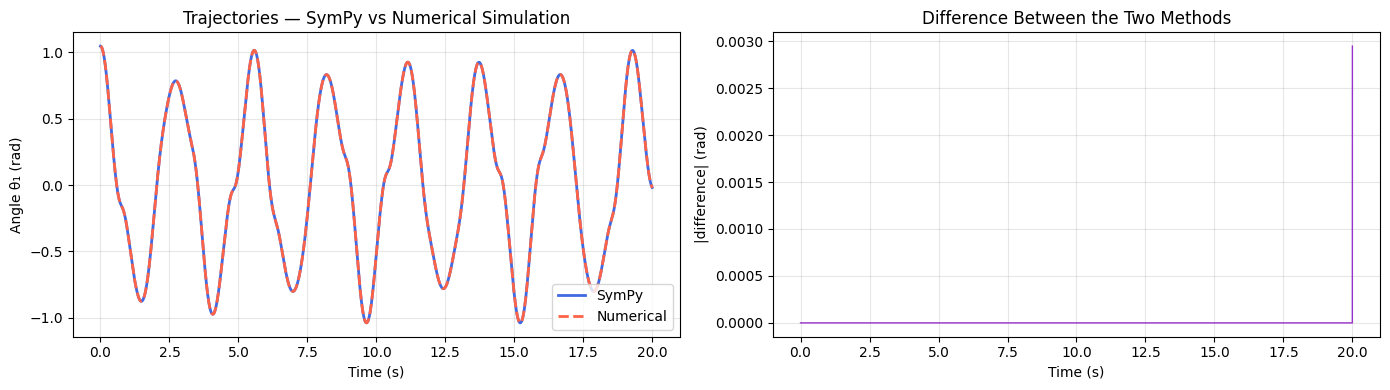

Maximum difference: 2.95e-03 rad
Methods agree.


In [12]:
print("Validation: comparing SymPy vs numerical simulation for N=2...")

result_sympy, _ = run_simulation(
    n=2,
    mass_values=[1.0, 1.0],
    length_values=[1.0, 1.0],
    angle_values=[np.pi/3, np.pi/4]
)

result_numeric = simulate_fast(
    n=2,
    masses=[1.0, 1.0],
    lengths=[1.0, 1.0],
    angles=[np.pi/3, np.pi/4]
)

min_len = min(len(result_sympy.t), len(result_numeric.t))
diff_val = np.abs(result_sympy.y[0, :min_len] - result_numeric.y[0, :min_len])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(result_sympy.t[:min_len], result_sympy.y[0, :min_len],
             label='SymPy', linewidth=2, color='royalblue')
axes[0].plot(result_numeric.t[:min_len], result_numeric.y[0, :min_len],
             '--', label='Numerical', linewidth=2, color='tomato')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angle θ₁ (rad)')
axes[0].set_title('Trajectories — SymPy vs Numerical Simulation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(result_sympy.t[:min_len], diff_val,
             color='darkorchid', linewidth=1)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('|difference| (rad)')
axes[1].set_title('Difference Between the Two Methods')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Maximum difference: {diff_val.max():.2e} rad")
print(f"Methods {'agree' if diff_val.max() < 1e-2 else 'disagree'}.")

In [ ]:
%matplotlib tk
try:
    N_ANIM = int(input("How many pendulums to animate? (2-10): "))
    N_ANIM = max(2, N_ANIM)
except ValueError:
    N_ANIM = 2
if N_ANIM > 8:
    print(f"Warning: N={N_ANIM} will take a long time to simulate!")

masses_anim = [1.0] * N_ANIM
lengths_anim = [1.0] * N_ANIM
angles_anim = [np.pi/2] * N_ANIM

result_anim = simulate_fast(N_ANIM, masses_anim, lengths_anim, angles_anim, t_span=(0, 20))

ani = animate_pendulum(result_anim, lengths_anim, n=N_ANIM, title=f"{N_ANIM}-Pendulum")


How many pendulums to animate? (2-10):  8


## 4. Lyapunov Exponent — Measuring Chaos

The Lyapunov exponent λ measures how quickly two nearby trajectories diverge. If two initial conditions differ by δ₀, the distance grows as:

$$\delta(t) \approx \delta_0 \cdot e^{\lambda t}$$

- **λ > 0** → chaos: small differences amplify exponentially
- **λ < 0** → order: the system forgets the initial difference  
- **λ = 0** → boundary between chaos and order

### Computation

We simulate two systems with a perturbation of δ₀ = 10⁻⁸ rad in the first angle and fit the slope of log(δ/δ₀) vs time. This gives the finite-time Lyapunov exponent.
We test N = 2 to 8. Beyond N=8, symbolic derivation with SymPy becomes 
impractically slow (complexity scales as O(N!)). The numerical method 
handles larger N but simulation time grows significantly.

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import ipywidgets as widgets
from IPython.display import display

text = widgets.BoundedIntText(value=2, min=2, description='Pendulum:')
button = widgets.Button(description='Animate')
output = widgets.Output()

def on_click(b):
    output.clear_output()
    with output:
        N_ANIM = text.value
        masses_anim  = [1.0] * N_ANIM
        lengths_anim = [1.0] * N_ANIM
        angles_anim  = [np.pi / 2] * N_ANIM
        result_anim = simulate_fast(N_ANIM, masses_anim, lengths_anim, angles_anim, t_span=(0, 20))
        animate_pendulum(result_anim, lengths_anim, n=N_ANIM, title=f"{N_ANIM}-Pendulum Animation")

button.on_click(on_click)
display(text, button, output)

In [ ]:
try:
    MAX_N = int(input("Enter maximum number of pendulums (recommended: 8): "))
    MAX_N = max(2, MAX_N)
except ValueError:
    MAX_N = 8

if MAX_N > 8:
    print("Warning: N > 8 may be slow!")

print()
lyapunov_results = {}

for n in range(2, MAX_N + 1):
    masses = [1.0] * n
    lengths = [1.0] * n
    angles = [np.pi/2] * n

    lyap = lyapunov_fast(n, masses, lengths, angles)
    lyapunov_results[n] = lyap
    print(f"N = {n}: λ = {lyap:.4f} ({'chaos' if lyap > 0 else 'order'})")

In [ ]:
ns = list(lyapunov_results.keys())
lyaps = list(lyapunov_results.values())

plt.figure(figsize=(10, 6))
plt.plot(ns, lyaps, 'o-', color='royalblue', linewidth=2, markersize=8)
plt.axhline(y=0, color='tomato', linestyle='--', linewidth=1.5, label='chaos/order boundary')
plt.xlabel('Number of pendulums N')
plt.ylabel('Lyapunov exponent λ')
plt.title('How chaos grows with the number of pendulums')
plt.xticks(ns)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Fractal Dimension — Geometry of Chaos

The trajectory of the last pendulum is a fractal curve — infinitely complex, never exactly repeating. We measure its complexity using the **box-counting algorithm**.

We cover the space with boxes of size ε and count N(ε) — how many contain at least one point. As ε decreases:

$$N(\varepsilon) \sim \varepsilon^{-D}$$

The fractal dimension D is the slope in the log-log plot:

$$D = -\lim_{\varepsilon \to 0} \frac{\log N(\varepsilon)}{\log \varepsilon}$$

- **D = 1** → simple curve (ordered motion)
- **D = 2** → fills the plane (maximum chaos)
- **1 < D < 2** → fractal (partial chaos)

In [ ]:
def box_counting_dimension(points, min_box=0.01, max_box=1.0, n_scales=20):
    """
    Estimate the fractal dimension of a 2D point set using box-counting.

    The space is covered with grids of decreasing box size epsilon.
    The fractal dimension D is the slope of log(N) vs log(1/epsilon),
    where N is the number of boxes containing at least one point.

    Parameters:
        points   : list of (x, y) tuples
        min_box  : smallest box size [same units as points]
        max_box  : largest box size [same units as points]
        n_scales : number of box sizes to test

    Returns:
        dimension : float — fractal dimension D
        scales    : array of box sizes used
        counts    : array of box counts at each scale
    """
    scales = np.logspace(np.log10(min_box), np.log10(max_box), n_scales)
    counts = []

    for scale in scales:
        boxes = set()
        for x, y in points:
            box_x = int(np.floor(x / scale))
            box_y = int(np.floor(y / scale))
            boxes.add((box_x, box_y))
        counts.append(len(boxes))

    log_scales = np.log(1.0 / scales)
    log_counts = np.log(counts)
    dimension = np.polyfit(log_scales, log_counts, 1)[0]

    return dimension, scales, counts

In [ ]:
print("Computing fractal dimension for N = 2 to MAX_N...")
fractal_results = {}

for n in range(2, MAX_N + 1):
    masses = [1.0] * n
    lengths = [1.0] * n
    angles_init = [np.pi/2] * n

    result = simulate_fast(n, masses, lengths, angles_init, t_span=(0, 60))

    angle_data = result.y[:n]
    last_x = np.zeros(len(result.t))
    last_y = np.zeros(len(result.t))

    for frame in range(len(result.t)):
        x, y = 0.0, 0.0
        for i in range(n):
            x = x + lengths[i] * np.sin(angle_data[i, frame])
            y = y - lengths[i] * np.cos(angle_data[i, frame])
        last_x[frame] = x
        last_y[frame] = y

    points = list(zip(last_x, last_y))
    dim, scales, counts = box_counting_dimension(points)
    fractal_results[n] = dim
    print(f"N = {n}: fractal dimension = {dim:.4f}")

In [ ]:
ns = list(fractal_results.keys())
dims = list(fractal_results.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ns, dims, 's-', color='darkorchid', linewidth=2, markersize=8)
axes[0].axhline(y=1.0, color='gray', linestyle=':', linewidth=1, label='straight line (D=1)')
axes[0].axhline(y=2.0, color='tomato', linestyle=':', linewidth=1, label='filled area (D=2)')
axes[0].set_xlabel('Number of pendulums N')
axes[0].set_ylabel('Fractal dimension D')
axes[0].set_title('Fractal complexity vs number of pendulums')
axes[0].set_xticks(ns)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

lyaps = [lyapunov_results[n] for n in ns]
ax2 = axes[1].twinx()
axes[1].plot(ns, lyaps, 'o-', color='royalblue', linewidth=2, markersize=8, label='Lyapunov λ')
ax2.plot(ns, dims, 's--', color='darkorchid', linewidth=2, markersize=8, label='Fractal D')
axes[1].set_xlabel('Number of pendulums N')
axes[1].set_ylabel('Lyapunov exponent λ', color='royalblue')
ax2.set_ylabel('Fractal dimension D', color='darkorchid')
axes[1].set_title('Lyapunov and fractal dimension — comparison')
axes[1].set_xticks(ns)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 6. Phase Diagram — Chaos vs Order

So far we tested only one set of initial conditions. Chaos depends strongly on starting angles. We compute λ for a 15×15 grid of 225 combinations of initial angles and visualize which lead to chaos.

In [ ]:
def phase_diagram(n, resolution=15, t_span=(0, 20)):
    
    angle_range = np.linspace(0.1, np.pi, resolution)
    
    chaos_map = np.zeros((resolution, resolution))
    
    total = resolution * resolution
    done = 0
    
    for i, a1 in enumerate(angle_range):
        for j, a2 in enumerate(angle_range):
            angles = [a1, a2] + [np.pi/4] * (n - 2)
            masses = [1.0] * n
            lengths = [1.0] * n
            
            lyap = lyapunov_fast(n, masses, lengths, angles, t_span=t_span)
            chaos_map[i, j] = lyap
            
            done += 1
            if done % 50 == 0:
                print(f"  {done}/{total} points computed...")
    
    return chaos_map, angle_range

In [ ]:
print("Phase diagram for N=2...")
print("Computing 225 simulations...\n")

chaos_map, angle_range = phase_diagram(n=2, resolution=15, t_span=(0, 20))

plt.figure(figsize=(8, 7))
plt.contourf(
    np.degrees(angle_range),
    np.degrees(angle_range),
    chaos_map,
    levels=50,
    cmap='RdBu_r'
)
plt.colorbar(label='Lyapunov exponent λ')
plt.xlabel('Initial angle of pendulum 1 (degrees)')
plt.ylabel('Initial angle of pendulum 2 (degrees)')
plt.title('Phase diagram — chaos (red) vs order (blue)')
plt.tight_layout()
plt.show()

print(f"\nMaximum λ: {chaos_map.max():.4f}")
print(f"Minimum λ: {chaos_map.min():.4f}")
print(f"Percentage of chaotic initial conditions: {(chaos_map > 0).mean() * 100:.1f}%")

## 7. Damping — How Friction Destroys Chaos

Without friction the system moves forever. We add viscous damping to the equations:

$$f_i \mathrel{-}= b \cdot \dot{\theta}_i \cdot l_i^2 \cdot \sum_{k=i}^{N} m_k$$

where b is the damping coefficient. We test b = 0, 0.1, 0.5, 1.0, 2.0 to study the transition from ideal frictionless chaos to dissipative real-world behavior.

In [ ]:
def get_derivatives_damped(t_val, y, n, masses, lengths, g=9.81, b=0.5):
    angles = y[:n]
    omegas = y[n:]

    M = np.zeros((n, n))
    f = np.zeros(n)

    for i in range(n):
        for j in range(n):
            m_sum = sum(masses[k] for k in range(max(i, j), n))
            M[i, j] = m_sum * lengths[i] * lengths[j] * np.cos(angles[i] - angles[j])

        m_sum_i = sum(masses[k] for k in range(i, n))
        f[i] = -sum(
            sum(masses[k] for k in range(max(i, j), n)) *
            lengths[i] * lengths[j] * omegas[j]**2 * np.sin(angles[i] - angles[j])
            for j in range(n)
        ) - m_sum_i * g * lengths[i] * np.sin(angles[i])

        
        f[i] -= b * omegas[i] * lengths[i]**2 * m_sum_i

    alphas = np.linalg.solve(M, f)
    return np.concatenate([omegas, alphas])


def simulate_damped(n, masses, lengths, angles, b=0.5, omegas=None, t_span=(0, 30)):
    if omegas is None:
        omegas = [0.0] * n

    y0 = np.array(list(angles) + list(omegas))

    result = solve_ivp(
        get_derivatives_damped,
        t_span,
        y0,
        args=(n, masses, lengths, 9.81, b),
        method='RK45',
        max_step=0.01,
        rtol=1e-8,
        atol=1e-8
    )
    return result

In [ ]:
damping_values = [0.0, 0.1, 0.5, 1.0, 2.0]
n = 2
masses = [1.0] * n
lengths = [1.0] * n
angles = [np.pi/2] * n

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lyapunov_damping = []

for b in damping_values:
    r1 = simulate_damped(n, masses, lengths, angles, b=b, t_span=(0, 30))

    angles_2 = list(angles)
    angles_2[0] += 1e-8
    r2 = simulate_damped(n, masses, lengths, angles_2, b=b, t_span=(0, 30))

    min_len = min(len(r1.t), len(r2.t))
    diff = np.zeros(min_len)
    for i in range(n):
        diff += (r1.y[i, :min_len] - r2.y[i, :min_len])**2
    diff = np.sqrt(diff)
    diff = diff[diff > 0]
    t_vals = r1.t[:len(diff)]
    log_diff = np.log(diff / 1e-8)
    lyap = np.polyfit(t_vals, log_diff, 1)[0]
    lyapunov_damping.append(lyap)

    last_x = np.zeros(len(r1.t))
    last_y = np.zeros(len(r1.t))
    for frame in range(len(r1.t)):
        x, y = 0.0, 0.0
        for i in range(n):
            x += lengths[i] * np.sin(r1.y[i, frame])
            y -= lengths[i] * np.cos(r1.y[i, frame])
        last_x[frame] = x
        last_y[frame] = y

    axes[0].plot(last_x, last_y, lw=0.5, alpha=0.7, label=f'b={b}')

axes[0].set_title('Trajectory of last pendulum at different damping values')
axes[0].set_xlabel('x (m)')
axes[0].set_ylabel('y (m)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

axes[1].plot(damping_values, lyapunov_damping, 'o-', color='tomato', linewidth=2, markersize=8)
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=1.5, label='chaos/order boundary')
axes[1].set_xlabel('Damping coefficient b')
axes[1].set_ylabel('Lyapunov exponent λ')
axes[1].set_title('Damping destroys chaos')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nResults:")
for b, lyap in zip(damping_values, lyapunov_damping):
    status = 'chaos' if lyap > 0 else 'order'
    print(f"b={b:.1f}: λ={lyap:.4f} ({status})")

## 8. Energy Conservation — Accuracy Check

Without damping, total mechanical energy E = T + V must be conserved. Significant energy drift would mean the simulation is unreliable and results cannot be trusted.

In [ ]:
n = 2
masses = [1.0] * n
lengths = [1.0] * n
angles_init = [np.pi/2] * n

result = simulate_fast(n, masses, lengths, angles_init, t_span=(0, 30))

energy = np.zeros(len(result.t))

for frame in range(len(result.t)):
    E = 0.0
    cum_y = np.zeros(n + 1)
    for i in range(n):
        cum_y[i+1] = cum_y[i] - lengths[i] * np.cos(result.y[i, frame])
    for i in range(n):
        vx, vy = 0.0, 0.0
        for j in range(i + 1):
            omega_j = result.y[n + j, frame]
            vx += lengths[j] * np.cos(result.y[j, frame]) * omega_j
            vy += lengths[j] * (-np.sin(result.y[j, frame])) * omega_j
        T = 0.5 * masses[i] * (vx**2 + vy**2)
        V = masses[i] * 9.81 * cum_y[i+1]
        E += T + V
    energy[frame] = E

drift = energy - energy[0]

plt.figure(figsize=(10, 4))
plt.plot(result.t, drift, color='royalblue', linewidth=1)
plt.axhline(y=0, color='tomato', linestyle='--', linewidth=1.5, label='zero drift')
plt.xlabel('Time (s)')
plt.ylabel('Energy deviation ΔE (J)')
plt.title('Simulation accuracy — energy deviation from initial value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

max_drift = np.abs(drift).max()
print(f"Maximum absolute deviation: {max_drift:.2e} J")
print(f"Simulation is {'accurate' if max_drift < 1e-4 else 'acceptable'} (RK45, rtol=1e-8)")

## 9. Poincaré Section — Structure of the Attractor

A Poincaré section is a classical tool in chaos theory. Instead of plotting the full trajectory, we record the state of the system only at specific moments — every time the first pendulum passes through θ₁ = 0 with positive angular velocity.

The resulting scatter plot reveals the **attractor structure**:
- A finite set of points → periodic (ordered) motion
- A closed curve → quasi-periodic motion
- A scattered cloud with structure → chaos

This gives a fundamentally different view of chaos than the Lyapunov exponent — it shows the geometry of long-term behavior directly.

In [ ]:
def poincare_section(n, masses, lengths, angles_init, t_span=(0, 500)):
    """
    Compute a Poincaré section for an N-pendulum system.

    Records the state of pendulum 2 every time pendulum 1 crosses theta=0
    from negative to positive. For large-angle configurations where pendulum 1
    makes full rotations, all upward crossings are recorded regardless.

    Parameters:
        n           : number of pendulums
        masses      : list of masses [kg]
        lengths     : list of rod lengths [m]
        angles_init : list of initial angles [rad]
        t_span      : (start, end) time in seconds

    Returns:
        section_theta2 : array of theta2 values at crossings [rad]
        section_omega2 : array of omega2 values at crossings [rad/s]
    """
    result = simulate_fast(n, masses, lengths, angles_init, t_span=t_span)

    theta1 = result.y[0]
    omega1 = result.y[n]

    section_theta2 = []
    section_omega2 = []

    for i in range(1, len(theta1)):
        if theta1[i-1] < 0 and theta1[i] >= 0:
            section_theta2.append(result.y[1, i])
            section_omega2.append(result.y[n+1, i])

    return np.array(section_theta2), np.array(section_omega2)


configs = [
    ([0.2, 0.2],         'Small angles (0.2 rad) — ordered'),
    ([np.pi/2, np.pi/2], 'Medium angles (π/2) — chaotic'),
    ([2.5, 2.5],         'Large angles (2.5 rad) — chaotic'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (init_angles, label) in enumerate(configs):
    theta2, omega2 = poincare_section(
        n=2,
        masses=[1.0, 1.0],
        lengths=[1.0, 1.0],
        angles_init=init_angles,
        t_span=(0, 500)
    )
    axes[idx].scatter(theta2, omega2, s=0.5, color='royalblue', alpha=0.6)
    axes[idx].set_xlabel('θ₂ (rad)')
    axes[idx].set_ylabel('ω₂ (rad/s)')
    axes[idx].set_title(label)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Poincaré Sections — Double Pendulum', fontsize=13)
plt.tight_layout()
plt.show()

for init_angles, label in configs:
    theta2, omega2 = poincare_section(2, [1.0,1.0], [1.0,1.0], init_angles, t_span=(0, 500))
    print(f"{label}: {len(theta2)} crossings recorded")


## Conclusion

### Findings

**Lyapunov Exponent:** λ stays between 0.84 and 1.00 for N = 2 to 8 — surprisingly stable. We expected chaos to grow with N, but it does not. This suggests the chaotic behavior is saturated already at N=2 and additional pendulums do not add new sources of instability.

**Fractal Dimension:** Decreases monotonically from 1.42 at N=2 to 1.06 at N=8. While λ stays constant, D drops — meaning the trajectory becomes geometrically simpler as N grows. Chaos spreads across more degrees of freedom but concentrates less in 2D physical space.

**Lyapunov vs Fractal:** These two metrics diverge as N increases — λ is flat while D drops. This shows they measure fundamentally different aspects of chaos: λ measures sensitivity to initial conditions, D measures geometric complexity.

**Phase Diagram:** 99.6% of initial conditions lead to chaos at N=2. The boundary between the chaotic and ordered regions is itself irregular — consistent with fractal structure.

**Damping:** A small damping of b=0.1 nearly eliminates chaos (λ drops from 0.90 to 0.005). At b=0.5 the system becomes fully ordered. This shows how fragile chaos is in the presence of even small energy dissipation.

### Answer to the Research Question

Chaos does not grow exponentially with N — the system is maximally chaotic already at N=2. Adding more pendulums does not amplify chaos but redistributes it into more complex geometry with lower fractal dimension. There is no critical N — the system is almost always chaotic for arbitrary initial conditions.

### Limitations and Next Steps

- The Lyapunov exponent here is a finite-time approximation. Longer simulations would improve accuracy.
- All pendulums have equal mass and length. Asymmetric configurations may produce different scaling behavior.
- A natural next step is computing the full **Lyapunov spectrum** — all N exponents simultaneously.

### References

1. Strogatz, S. H. (1994). *Nonlinear Dynamics and Chaos*. Westview Press.  
   *Theoretical foundation for Lyapunov exponents and chaos theory.*

2. Shinbrot, T., Grebogi, C., Wisdom, J., & Yorke, J. A. (1992). Chaos in a double pendulum. *American Journal of Physics*, 60(6), 491–499.  
   *Original paper demonstrating chaotic behavior in the double pendulum.*

3. Mandelbrot, B. B. (1982). *The Fractal Geometry of Nature*. W. H. Freeman.  
   *Definition and theory of fractal dimension and box-counting.*

4. SciPy documentation: `solve_ivp` —   
   https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html  
   *RK45 integrator used for all numerical simulations.*